In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.metrics import Precision, Recall
!pip install shap lime
import shap
import lime
import lime.lime_tabular
import seaborn as sns

In [40]:
Products = pd.read_csv('olist_products_dataset.csv')

Reviews = pd.read_csv('olist_order_reviews_dataset.csv')

Order_Items = pd.read_csv('olist_order_items_dataset.csv')

Customers = pd.read_csv('olist_customers_dataset.csv')

Orders = pd.read_csv('olist_orders_dataset.csv')


In [41]:
Products.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [42]:
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [43]:
Products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [44]:
Products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [45]:
Products = Products.dropna(subset=[
    'product_name_lenght'
])

In [46]:
Products[Products.isnull().any(axis=1)]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN


In [47]:
#drop  the product with product_weight_g null
Products = Products.dropna(subset=['product_weight_g'])


In [48]:
Reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [49]:
Reviews = Reviews.drop(columns=['review_comment_title'])
Reviews = Reviews.drop(columns=['review_comment_message'])

In [50]:
Reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [51]:
Reviews.head(10)

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,2018-05-22 00:00:00,2018-05-23 16:45:47


In [52]:
#convert timestamps to datetime datatype (review_creation_date	review_answer_timestamp)
Reviews['review_creation_date'] = pd.to_datetime(Reviews['review_creation_date'])
Reviews['review_answer_timestamp'] = pd.to_datetime(Reviews['review_answer_timestamp'])

In [53]:
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [54]:
Orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [55]:
Orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [56]:
Orders[Orders.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [57]:
shipped_orders = Orders[Orders['order_status'] == 'delivered'].copy()
shipped_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [58]:
Orders['order_status'].unique()


array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [59]:
# Filter orders with no delivery date
missing_delivery = Orders[Orders['order_delivered_customer_date'].isnull()]

# See what their statuses are
missing_delivery['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [60]:
Orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [61]:
#convert timestamps to datetime datatype (order_purchase_timestamp	order_approved_at	order_delivered_carrier_date	order_delivered_customer_date	order_estimated_delivery_date)
Orders['order_purchase_timestamp'] = pd.to_datetime(Orders['order_purchase_timestamp'])
Orders['order_approved_at'] = pd.to_datetime(Orders['order_approved_at'])
Orders['order_delivered_carrier_date'] = pd.to_datetime(Orders['order_delivered_carrier_date'])
Orders['order_delivered_customer_date'] = pd.to_datetime(Orders['order_delivered_customer_date'])
Orders['order_estimated_delivery_date'] = pd.to_datetime(Orders['order_estimated_delivery_date'])


In [62]:
# ✅ Calculate the delivery time difference (keeps NaNs if any date is missing)
Orders['delivery_delay'] = Orders['order_delivered_customer_date'] - Orders['order_estimated_delivery_date']

# ✅ Create a filtered DataFrame with only valid (non-null) differences
valid_diff = Orders[Orders['delivery_delay'].notna()]


In [63]:
# Filter canceled orders that somehow have a delivery date
canceled_with_delivery = Orders[
    (Orders['order_status'] == 'canceled') &
    (Orders['order_delivered_customer_date'].notnull())
]

# Show the relevant columns
canceled_with_delivery[['order_id', 'order_status', 'order_delivered_customer_date', 'order_estimated_delivery_date']].head(10)

,order_id,order_status,order_delivered_customer_date,order_estimated_delivery_date
2921,1950d777989f6a877539f53795b4c3c3,canceled,2018-03-21 22:03:51,2018-03-09
8791,dabf2b0e35b423f94618bf965fcb7514,canceled,2016-10-16 14:36:59,2016-11-30
58266,770d331c84e5b214bd9dc70a10b829d0,canceled,2016-10-14 15:07:11,2016-11-29
59332,8beb59392e21af5eb9547ae1a9938d06,canceled,2016-10-19 18:47:43,2016-11-30
92636,65d1e226dfaeb8cdc42f665422522d14,canceled,2016-11-08 10:58:34,2016-11-25
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,canceled,2016-11-09 14:53:50,2016-12-08


In [64]:
canceled_with_delivery[['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']].head(10)

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
2921,2018-02-19 19:48:52,2018-03-21 22:03:51,2018-03-09
8791,2016-10-09 00:56:52,2016-10-16 14:36:59,2016-11-30
58266,2016-10-07 14:52:30,2016-10-14 15:07:11,2016-11-29
59332,2016-10-08 20:17:50,2016-10-19 18:47:43,2016-11-30
92636,2016-10-03 21:01:41,2016-11-08 10:58:34,2016-11-25
94399,2016-10-09 15:39:56,2016-11-09 14:53:50,2016-12-08


In [65]:
# Select delivered orders
delivered_orders = Orders['order_status'] == 'delivered'

# Update their delivery date to be the estimated delivery date
Orders.loc[delivered_orders, 'order_delivered_customer_date'] = Orders.loc[delivered_orders, 'order_estimated_delivery_date']

# Check the first few updated rows
Orders[delivered_orders][['order_id', 'order_status', 'order_delivered_customer_date', 'order_estimated_delivery_date']].head()

,order_id,order_status,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-18,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-08-13,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-09-04,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-12-15,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-26,2018-02-26


In [66]:
not_delivered = Orders[Orders['order_delivered_customer_date'].isnull()]
not_delivered['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [67]:
Orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-18,2017-10-18,-8 days +21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-13,2018-08-13,-6 days +15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-09-04,2018-09-04,-18 days +18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-15,2017-12-15,-13 days +00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-26,2018-02-26,-10 days +18:17:02


In [68]:
Order_Items.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [69]:
#convert timestamps to datetime datatype (shipping_limit_date)
Order_Items['shipping_limit_date'] = pd.to_datetime(Order_Items['shipping_limit_date'])

In [70]:
Order_Items['shipping_limit_date'].dtypes

dtype('<M8[ns]')

In [71]:
Customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [72]:
Orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-18,2017-10-18,-8 days +21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-13,2018-08-13,-6 days +15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-09-04,2018-09-04,-18 days +18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-15,2017-12-15,-13 days +00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-26,2018-02-26,-10 days +18:17:02
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-08-01,2017-08-01,-6 days +10:57:55
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,NaT
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-06-07,2017-06-07,-12 days +12:55:51
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-03-06,2017-03-06,-32 days +14:08:10
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-23,2017-08-23,-7 days +17:14:30


In [73]:
#check nulls in all datasets
Products.isnull().sum()


,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [74]:
Reviews.isnull().sum()


,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [75]:
Orders.isnull().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2957
order_estimated_delivery_date,0
delivery_delay,2965


In [76]:
# Drop rows where order_status is 'delivered' and order_delivered_customer_date is NaN
Orders = Orders[~((Orders['order_status'] == 'delivered') & (Orders['order_delivered_customer_date'].isnull()))]

In [77]:
# Check if any delivered orders still have null delivery date
Orders[(Orders['order_status'] == 'delivered') & (Orders['order_delivered_customer_date'].isnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay


In [78]:
Order_Items.isnull().sum()


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [79]:
Customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [80]:
# Start with Order_Items (most granular level)
mergeddf = Order_Items.merge(Products, on='product_id', how='inner')
mergeddf = mergeddf.merge(Orders, on='order_id', how='inner')
mergeddf = mergeddf.merge(Customers, on='customer_id', how='left')
mergeddf = mergeddf.merge(Reviews, on='order_id', how='inner')  # Fixed variable name

# Check for duplicates
print(f"Shape after merges: {mergeddf.shape}")
print(f"Original Order_Items shape: {Order_Items.shape}")

Shape after merges: (110773, 31)
Original Order_Items shape: (112650, 7)


In [81]:
mergeddf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110773 entries, 0 to 110772
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       110773 non-null  object         
 1   order_item_id                  110773 non-null  int64          
 2   product_id                     110773 non-null  object         
 3   seller_id                      110773 non-null  object         
 4   shipping_limit_date            110773 non-null  datetime64[ns] 
 5   price                          110773 non-null  float64        
 6   freight_value                  110773 non-null  float64        
 7   product_category_name          110773 non-null  object         
 8   product_name_lenght            110773 non-null  float64        
 9   product_description_lenght     110773 non-null  float64        
 10  product_photos_qty             110773 non-null  float64 

In [82]:
mergeddf.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0


   customer_state   product_category_name  avg_review_score  review_count
0              BA  informatica_acessorios          3.949612           258
1              CE            beleza_saude          3.854545           165
2              DF           esporte_lazer          4.132743           226
3              ES           esporte_lazer          4.179191           173
4              GO           esporte_lazer          4.144578           166
5              MG        malas_acessorios          4.426230           183
6              PE            beleza_saude          4.054852           237
7              PR              perfumaria          4.392157           153
8              RJ            beleza_saude          4.063208          1060
9              RS              perfumaria          4.350649           154
10             SC      relogios_presentes          4.157609           184
11             SP  livros_interesse_geral          4.486726           226

Number of states analyzed after filte

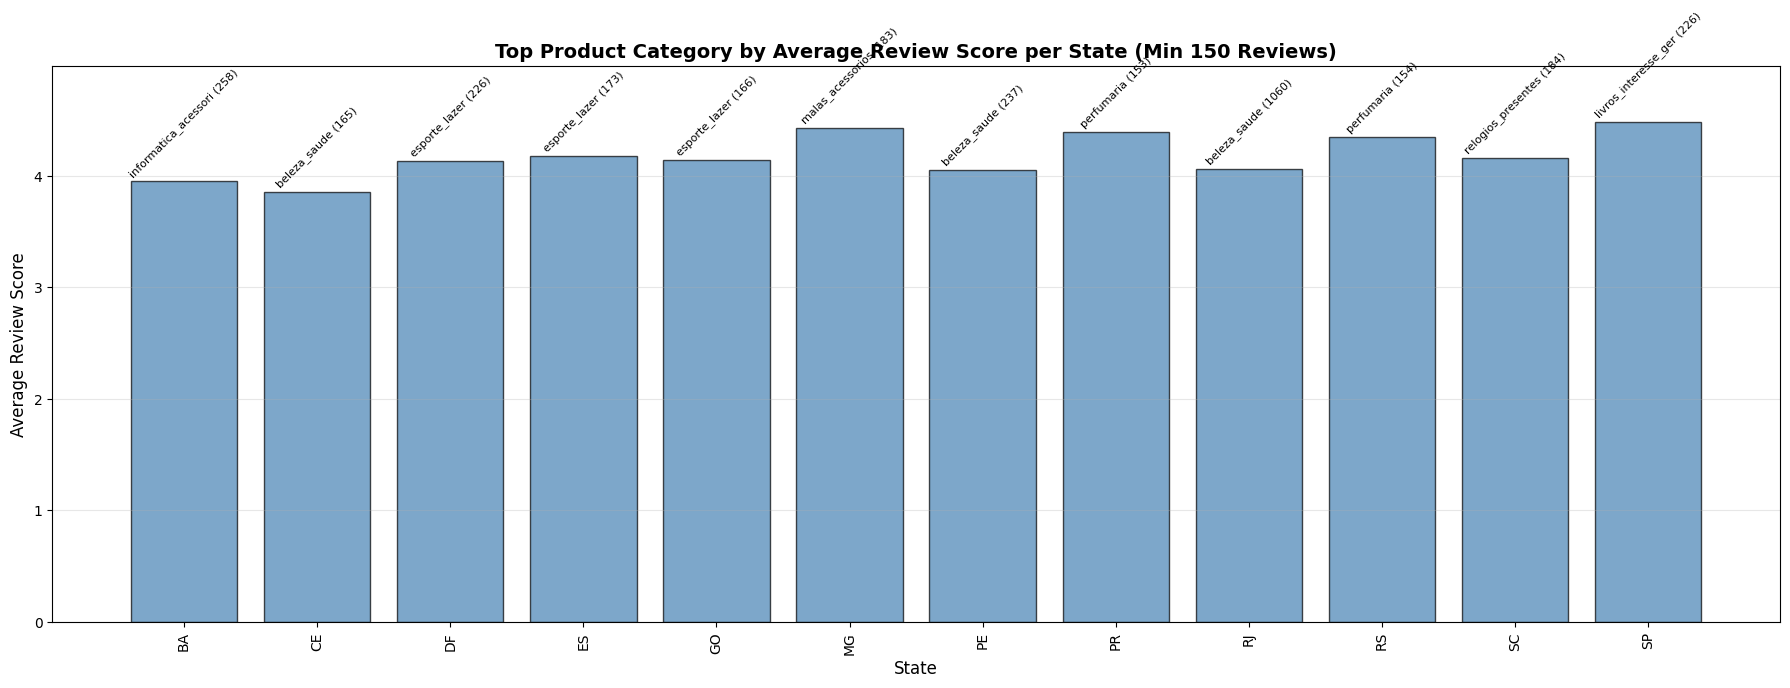

In [83]:
# --------------------------
# 1️⃣ Compute average review score and count per state and product category
# --------------------------
avg_scores = mergeddf.groupby(
    ['customer_state', 'product_category_name']
).agg(
    avg_review_score=('review_score', 'mean'),
    review_count=('review_score', 'count')
).reset_index()

# --------------------------
# 2️⃣ Filter for categories with a minimum number of reviews (e.g., 10 or more)
# --------------------------
min_reviews_threshold = 150  # You can adjust this threshold
filtered_scores = avg_scores[avg_scores['review_count'] >= min_reviews_threshold].copy()


# --------------------------
# 3️⃣ Find the top product category per state from the filtered data
# --------------------------
# Handle cases where a state might not have any categories meeting the threshold
top_categories = filtered_scores.loc[
    filtered_scores.groupby('customer_state')['avg_review_score'].idxmax()
].sort_values('customer_state').reset_index(drop=True)

# --------------------------
# 4️⃣ Display the results
# --------------------------
print(top_categories)
print(f"\nNumber of states analyzed after filtering: {len(top_categories)}")


# --------------------------
# 5️⃣ Improved Visualization (update to use filtered_scores and correct column name)
# --------------------------
plt.figure(figsize=(18, 7)) # Increased figure size for better readability
bars = plt.bar(
    range(len(top_categories)),
    top_categories['avg_review_score'], # Use avg_review_score
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)

# Set x-axis labels to state names
plt.xticks(range(len(top_categories)), top_categories['customer_state'], rotation=90)

# Add category names on top of bars
for i, row in top_categories.iterrows():
    plt.text(
        i,
        row['avg_review_score'] + 0.02,  # Use avg_review_score
        f"{row['product_category_name'][:20]} ({row['review_count']})",  # Add review count
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45
    )

plt.title(f'Top Product Category by Average Review Score per State (Min {min_reviews_threshold} Reviews)', fontsize=14, fontweight='bold')
plt.ylabel('Average Review Score', fontsize=12)
plt.xlabel('State', fontsize=12)
plt.ylim(0, top_categories['avg_review_score'].max() + 0.5)  # Use avg_review_score
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
#● Which product category has the highest average review score in each region? Q1

# calculate the average number of reviews on each product category
avg_reviews_per_category = mergeddf.groupby('product_category_name')['review_score'].count()
print (avg_reviews_per_category)





product_category_name
agro_industria_e_comercio     212
alimentos                     495
alimentos_bebidas             279
artes                         207
artes_e_artesanato             24
                             ... 
sinalizacao_e_seguranca       197
tablets_impressao_imagem       81
telefonia                    4517
telefonia_fixa                262
utilidades_domesticas        6943
Name: review_score, Length: 73, dtype: int64


In [89]:
# Filter for delivered orders
delivered_orders = mergeddf[mergeddf['order_status'] == 'delivered']

# Calculate the average delivery delay for delivered orders (in days)
average_delivery_delay_delivered = delivered_orders['delivery_delay'].mean()

# Convert Timedelta to days (float)
average_delay_days = average_delivery_delay_delivered / pd.Timedelta(days=1)

print(f"Average delivery delay for delivered orders: {average_delay_days:.2f} days")

# Print number of review scores (count, not sum)
print(f"Number of review scores: {mergeddf['review_score'].count()}")


Average delivery delay for delivered orders: -11.38 days
Number of review scores: 110773


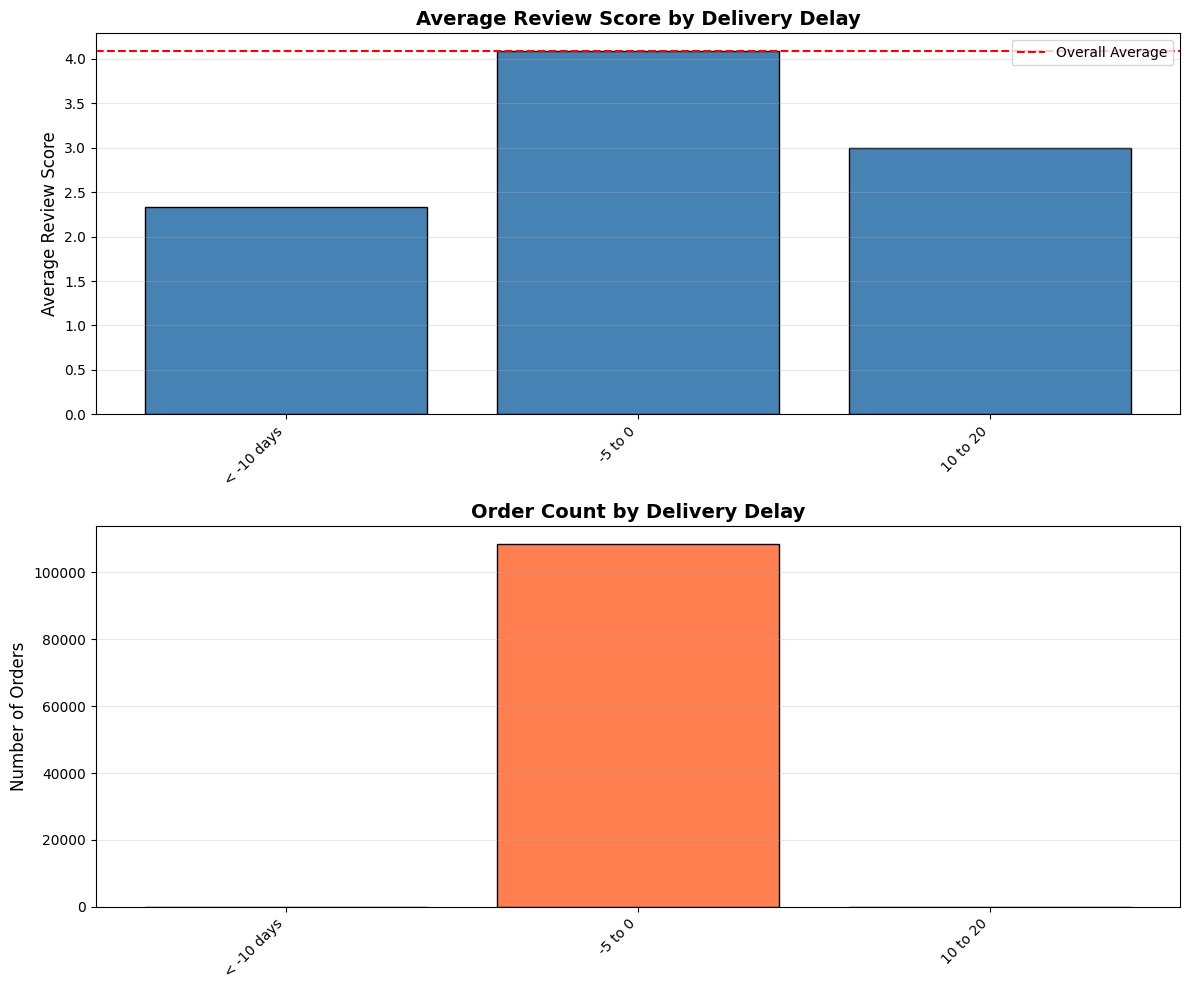

Summary of Delivery Delay vs Review Score:
    delay_bin  avg_review_score   count
0  < -10 days          2.333333       6
1     -5 to 0          4.083297  108479
2    10 to 20          3.000000       1

Correlation between delivery_delay and review_score: 0.007


In [90]:
# Ensure date columns are in datetime format
mergeddf['order_delivered_customer_date'] = pd.to_datetime(mergeddf['order_delivered_customer_date'])
mergeddf['order_estimated_delivery_date'] = pd.to_datetime(mergeddf['order_estimated_delivery_date'])

# Calculate delivery delay
mergeddf['delivery_delay'] = (mergeddf['order_delivered_customer_date'] -
                               mergeddf['order_estimated_delivery_date']).dt.days

# Drop rows with NaN values
mergeddf_cleaned = mergeddf.dropna(subset=['delivery_delay', 'review_score']).copy()

# Create delay bins
mergeddf_cleaned['delay_bin'] = pd.cut(
    mergeddf_cleaned['delivery_delay'],
    bins=[-float('inf'), -10, -5, 0, 5, 10, 20, 30, float('inf')],
    labels=['< -10 days', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 20', '20 to 30', '> 30 days']
)

# Calculate average review score per bin
delay_review = mergeddf_cleaned.groupby('delay_bin', observed=True).agg({
    'review_score': ['mean', 'count']
}).reset_index()
delay_review.columns = ['delay_bin', 'avg_review_score', 'count']

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Average review score by delay bin
ax1.bar(range(len(delay_review)), delay_review['avg_review_score'], color='steelblue', edgecolor='black')
ax1.set_xticks(range(len(delay_review)))
ax1.set_xticklabels(delay_review['delay_bin'], rotation=45, ha='right')
ax1.set_ylabel('Average Review Score', fontsize=12)
ax1.set_title('Average Review Score by Delivery Delay', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=mergeddf_cleaned['review_score'].mean(), color='red', linestyle='--', label='Overall Average')
ax1.legend()

# Plot 2: Count of orders per bin
ax2.bar(range(len(delay_review)), delay_review['count'], color='coral', edgecolor='black')
ax2.set_xticks(range(len(delay_review)))
ax2.set_xticklabels(delay_review['delay_bin'], rotation=45, ha='right')
ax2.set_ylabel('Number of Orders', fontsize=12)
ax2.set_title('Order Count by Delivery Delay', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary of Delivery Delay vs Review Score:")
print(delay_review)
print(f"\nCorrelation between delivery_delay and review_score: {mergeddf_cleaned[['delivery_delay', 'review_score']].corr().iloc[0,1]:.3f}")

States with Highest Proportion of Negative Reviews:
   customer_state  negative_count  total_reviews  negative_proportion  \
21             RR              13             50             0.260000   
1              AL             109            441             0.247166   
9              MA             188            812             0.231527   
18             RJ            3206          14250             0.224982   
24             SE              82            381             0.215223   
5              CE             304           1454             0.209078   
13             PA             219           1048             0.208969   
4              BA             741           3708             0.199838   
16             PI              99            531             0.186441   
2              AM              30            162             0.185185   

    negative_percentage  
21            26.000000  
1             24.716553  
9             23.152709  
18            22.498246  
24            

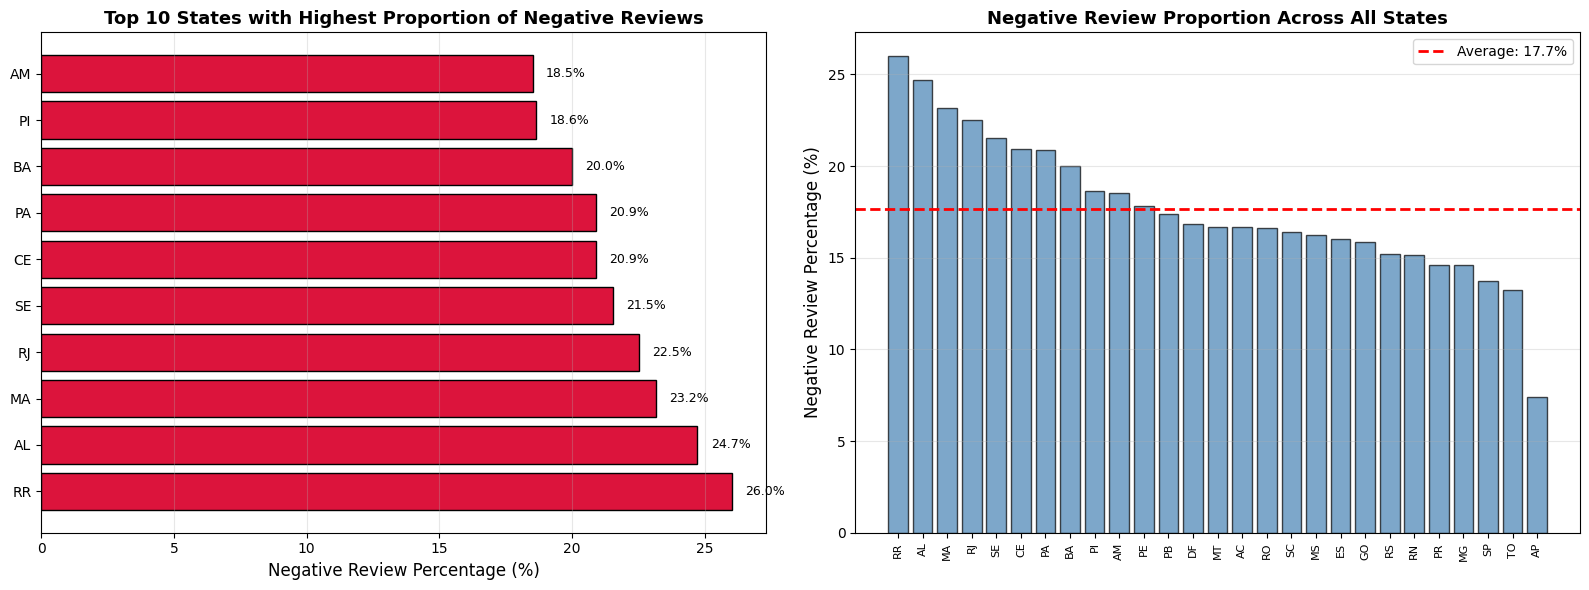


Overall negative review rate: 16.03%
State with highest negative reviews: RR (26.00%)
State with lowest negative reviews: AP (7.41%)


In [91]:
# --------------------------
# 1️⃣ Define negative reviews (typically scores 1-2 or 1-3)
# --------------------------
# Using 1-2 as negative (you can adjust to 1-3 if needed)
mergeddf['is_negative'] = mergeddf['review_score'] <= 2

# --------------------------
# 2️⃣ Calculate proportion of negative reviews per state
# --------------------------
negative_by_state = mergeddf.groupby('customer_state').agg({
    'is_negative': ['sum', 'count', 'mean']
}).reset_index()

negative_by_state.columns = ['customer_state', 'negative_count', 'total_reviews', 'negative_proportion']
negative_by_state['negative_percentage'] = negative_by_state['negative_proportion'] * 100

# Sort by proportion descending
negative_by_state = negative_by_state.sort_values('negative_proportion', ascending=False)

# --------------------------
# 3️⃣ Display results
# --------------------------
print("States with Highest Proportion of Negative Reviews:")
print(negative_by_state.head(10))

# --------------------------
# 4️⃣ Visualization
# --------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 10 states by negative review proportion
top_10_negative = negative_by_state.head(10)
ax1.barh(range(len(top_10_negative)), top_10_negative['negative_percentage'], color='crimson', edgecolor='black')
ax1.set_yticks(range(len(top_10_negative)))
ax1.set_yticklabels(top_10_negative['customer_state'])
ax1.set_xlabel('Negative Review Percentage (%)', fontsize=12)
ax1.set_title('Top 10 States with Highest Proportion of Negative Reviews', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add percentage labels on bars
for i, (idx, row) in enumerate(top_10_negative.iterrows()):
    ax1.text(row['negative_percentage'] + 0.5, i, f"{row['negative_percentage']:.1f}%",
             va='center', fontsize=9)

# Plot 2: All states map view
ax2.bar(range(len(negative_by_state)), negative_by_state['negative_percentage'],
        color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xticks(range(len(negative_by_state)))
ax2.set_xticklabels(negative_by_state['customer_state'], rotation=90, fontsize=8)
ax2.set_ylabel('Negative Review Percentage (%)', fontsize=12)
ax2.set_title('Negative Review Proportion Across All States', fontsize=13, fontweight='bold')
ax2.axhline(y=negative_by_state['negative_percentage'].mean(), color='red',
            linestyle='--', linewidth=2, label=f"Average: {negative_by_state['negative_percentage'].mean():.1f}%")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------
# 5️⃣ Summary Statistics
# --------------------------
print(f"\nOverall negative review rate: {mergeddf['is_negative'].mean() * 100:.2f}%")
print(f"State with highest negative reviews: {negative_by_state.iloc[0]['customer_state']} ({negative_by_state.iloc[0]['negative_percentage']:.2f}%)")
print(f"State with lowest negative reviews: {negative_by_state.iloc[-1]['customer_state']} ({negative_by_state.iloc[-1]['negative_percentage']:.2f}%)")